In [1]:
import numpy as np
import pandas as pd
import anndata
import os
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA
from sklearn import preprocessing
from matplotlib.colors import ListedColormap
from matplotlib.cm import get_cmap

/tmp/ipykernel_1638957/2422706940.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["seurat_clusters"] = meta_all["seurat_clusters"].values.astype(str)


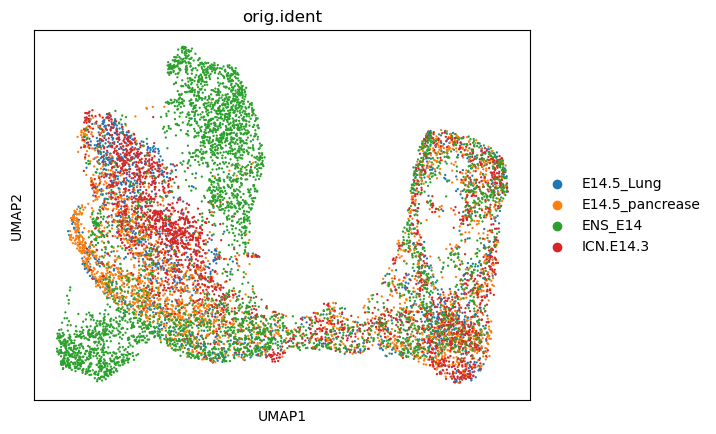

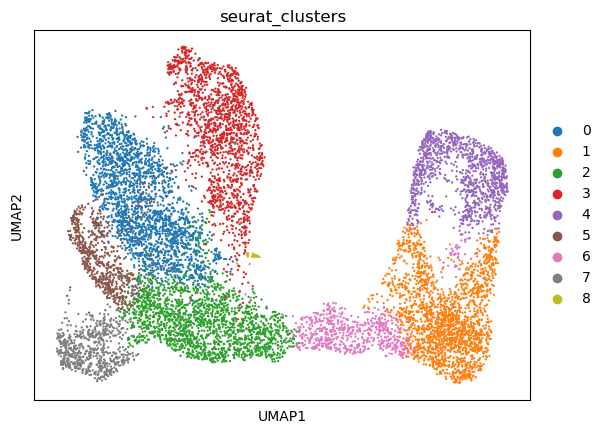

In [2]:
### Load integrated result together with seurat clusters and slingshot result
# Note: adata.X here is after sc.pp.normalize_total and sc.pp.log1p

adata = sc.read_h5ad(res_path + "/Mar25_portal_4organOIN_withoutNPC_v1.h5ad")
barcode_list = ["-".join(txt.split("-")[:-1]) for txt in list(adata.obs.index)]
adata.obs.index = barcode_list

res_path = "/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/ref_fig6_embryopaper/data"
meta_all = pd.read_csv(res_path + "/meta_all.csv", index_col=0)

adata = adata[meta_all.index, :]
adata.obs["seurat_clusters"] = meta_all["seurat_clusters"].values.astype(str)
adata.obs["slingPseudotime_1"] = meta_all["slingPseudotime_1"].values
adata.obs["slingPseudotime_2"] = meta_all["slingPseudotime_2"].values
adata.obs["slingPseudotime_3"] = meta_all["slingPseudotime_3"].values
adata.obs["slingPseudotime_4"] = meta_all["slingPseudotime_4"].values
adata.obs["slingPseudotime_5"] = meta_all["slingPseudotime_5"].values

res_path = "/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/oin_trajectory_integration_portal_harmony/results_portal"
lowdim_df = pd.read_csv(res_path + "/Mar25_portal_4organOIN_withoutNPC_v1_lowdim.csv", index_col=0)
barcode_list = ["-".join(txt.split("-")[:-1]) for txt in list(lowdim_df.index)]
lowdim_df.index = barcode_list
lowdim_df = lowdim_df.loc[adata.obs.index, :]
adata.obsm["lowdim_portal"] = lowdim_df

# adata = adata[adata.obs["seurat_clusters"].values.astype(str) != "1", :]
# adata = adata[adata.obs["seurat_clusters"].values.astype(str) != "4", :]

sc.pl.umap(adata, color=["orig.ident"])
sc.pl.umap(adata, color=["seurat_clusters"])

/tmp/ipykernel_1638957/208192805.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs["cell_state"][(adata.obs["seurat_clusters"].values.astype(str) == "1") |
/tmp/ipykernel_1638957/208192805.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs["cell_state"][(adata.obs["seurat_clusters"].values.astype(str) == "2") |
/tmp/ipykernel_1638957/208192805.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs["cell_st

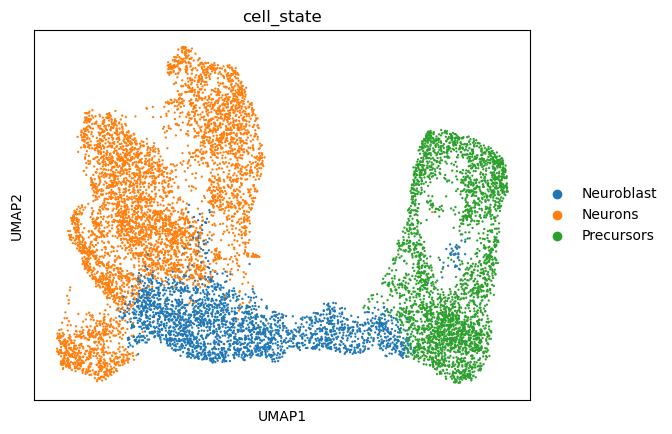

In [3]:
adata.obs["cell_state"] = ""
adata.obs["cell_state"][(adata.obs["seurat_clusters"].values.astype(str) == "1") | 
                        (adata.obs["seurat_clusters"].values.astype(str) == "4")] = "Precursors"
adata.obs["cell_state"][(adata.obs["seurat_clusters"].values.astype(str) == "2") | 
                        (adata.obs["seurat_clusters"].values.astype(str) == "6")] = "Neuroblast"
adata.obs["cell_state"][(adata.obs["seurat_clusters"].values.astype(str) == "0") | 
                        (adata.obs["seurat_clusters"].values.astype(str) == "3") | 
                        (adata.obs["seurat_clusters"].values.astype(str) == "5") |
                        (adata.obs["seurat_clusters"].values.astype(str) == "7") | 
                        (adata.obs["seurat_clusters"].values.astype(str) == "8")] = "Neurons"
sc.pl.umap(adata, color=["cell_state"])

In [4]:
### only keep trajectory 1-4
adata.obs["pseudotime1to4"] = np.nanmean(adata.obs[["slingPseudotime_1","slingPseudotime_2","slingPseudotime_3","slingPseudotime_4"]].values, axis=1)

/tmp/ipykernel_1638957/2574987718.py:2: RuntimeWarning: Mean of empty slice
  adata.obs["pseudotime1to4"] = np.nanmean(adata.obs[["slingPseudotime_1","slingPseudotime_2","slingPseudotime_3","slingPseudotime_4"]].values, axis=1)


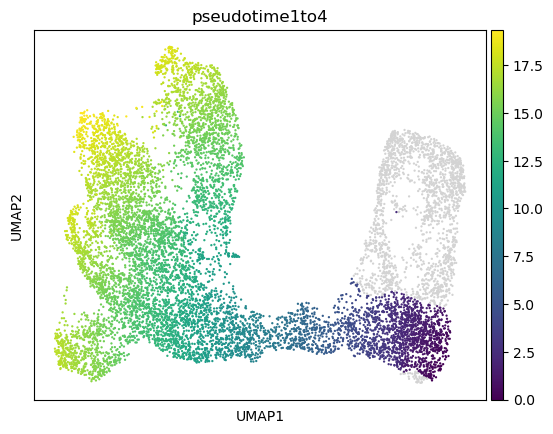

In [5]:
sc.pl.umap(adata, color=["pseudotime1to4"])

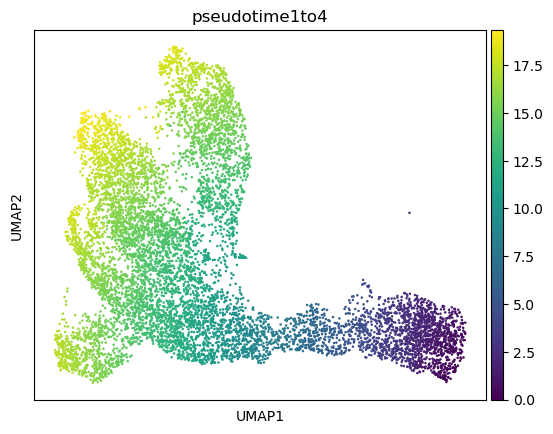

In [6]:
# get pseudotime range for the 3 cell states
idx_pst = [(not np.isnan(adata.obs["pseudotime1to4"].values[i])) for i in range(adata.shape[0])]
adata_pst = adata[idx_pst, :]
sc.pl.umap(adata_pst, color=["pseudotime1to4"])

adata = adata_pst.copy()

In [7]:
cutoff_1 = np.quantile(adata_pst.obs["pseudotime1to4"].values[adata_pst.obs["cell_state"] == "Precursors"], 0.99)
cutoff_1 = cutoff_1 + np.quantile(adata_pst.obs["pseudotime1to4"].values[adata_pst.obs["cell_state"] == "Neuroblast"], 0.01)
cutoff_1 = cutoff_1 / 2
cutoff_1

3.9659309738075756

In [8]:
cutoff_2 = np.quantile(adata_pst.obs["pseudotime1to4"].values[adata_pst.obs["cell_state"] == "Neuroblast"], 0.99)
cutoff_2 = cutoff_2 + np.quantile(adata_pst.obs["pseudotime1to4"].values[adata_pst.obs["cell_state"] == "Neurons"], 0.01)
cutoff_2 = cutoff_2 / 2
cutoff_2

12.815343374020156

In [9]:
### find hvgs

data_path = "/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/oin_trajectory_integration_portal_harmony/preprocessed_data"
adata_heart = sc.read_h5ad(data_path + "/oin_heart.h5ad")
adata_gut = sc.read_h5ad(data_path + "/oin_gut.h5ad")
adata_lung = sc.read_h5ad(data_path + "/oin_lung.h5ad")
adata_pan = sc.read_h5ad(data_path + "/oin_pan.h5ad")

# adata_heart = adata_heart[adata[adata.obs["orig.ident"] == "ICN.E14.3", :].obs.index, :]
# adata_gut = adata_gut[adata[adata.obs["orig.ident"] == "ENS_E14", :].obs.index, :]
# adata_lung = adata_lung[adata[adata.obs["orig.ident"] == "E14.5_Lung", :].obs.index, :]
# adata_pan = adata_pan[adata[adata.obs["orig.ident"] == "E14.5_pancrease", :].obs.index, :]

hvg_num = 1000
adata_list = [adata_heart, adata_gut, adata_lung, adata_pan]
for i, adata_tmp in enumerate(adata_list):
    sc.pp.highly_variable_genes(adata_tmp, flavor='seurat_v3', n_top_genes=hvg_num)
    hvg = adata_tmp.var[adata_tmp.var.highly_variable == True].sort_values(by="highly_variable_rank").index
    if i == 0:
        hvg_total = hvg
    else:
        hvg_total = hvg_total | hvg

for i, adata_tmp in enumerate(adata_list):
    sc.pp.normalize_total(adata_tmp, target_sum=1e4)
    sc.pp.log1p(adata_tmp)
    adata_tmp = adata_tmp[:, hvg_total]
    # sc.pp.scale(adata_tmp, max_value=10)
    if i == 0:
        adata_total = adata_tmp
    else:
        adata_total = adata_total.concatenate(adata_tmp, index_unique=None)

sc.pp.scale(adata_total, max_value=10)

adata_total = adata_total[adata.obs.index, :]
npcs = 50
pca = PCA(n_components=npcs, svd_solver="arpack", random_state=0)
adata.obsm["X_pca"] = pca.fit_transform(adata_total.X)

/tmp/ipykernel_1638957/3599359783.py:22: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead.
  hvg_total = hvg_total | hvg
/tmp/ipykernel_1638957/3599359783.py:22: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead.
  hvg_total = hvg_total | hvg
/tmp/ipykernel_1638957/3599359783.py:22: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead.
  hvg_total = hvg_total | hvg
/home/jz874/.conda/envs/grace_portal_env_torch1/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutori

/home/jz874/.conda/envs/grace_portal_env_torch1/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP(angular_rp_forest=True, local_connectivity=1, metric='correlation', min_dist=0.3, n_neighbors=30, random_state=1234, repulsion_strength=1, verbose=True)
Fri Mar 28 14:17:54 2025 Construct fuzzy simplicial set
Fri Mar 28 14:17:54 2025 Finding Nearest Neighbors
Fri Mar 28 14:17:54 2025 Building RP forest with 10 trees
Fri Mar 28 14:17:57 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Fri Mar 28 14:18:05 2025 Finished Nearest Neighbor Search
Fri Mar 28 14:18:07 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Mar 28 14:18:28 2025 Finished embedding


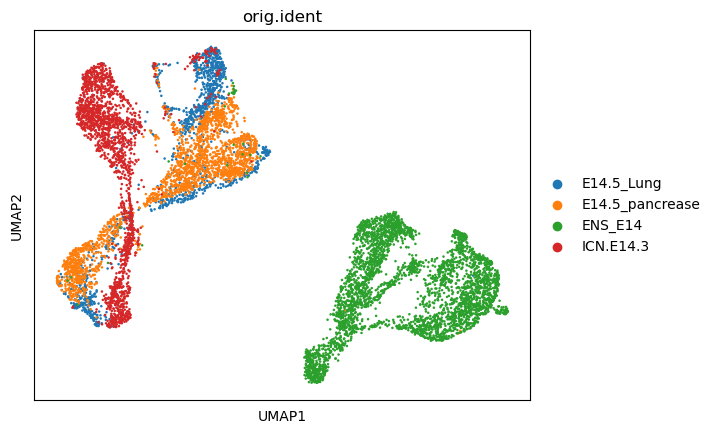

In [10]:
adata_plot = adata.copy()

import umap
reducer = umap.UMAP(n_neighbors=30,
                    n_components=2,
                    metric="correlation",
                    n_epochs=None,
                    learning_rate=1.0,
                    min_dist=0.3,
                    spread=1.0,
                    set_op_mix_ratio=1.0,
                    local_connectivity=1,
                    repulsion_strength=1,
                    negative_sample_rate=5,
                    a=None,
                    b=None,
                    random_state=1234,
                    metric_kwds=None,
                    angular_rp_forest=False,
                    verbose=True)
embedding = reducer.fit_transform(adata.obsm["X_pca"])
adata_plot.obsm["X_umap"] = embedding
sc.pl.umap(adata_plot, color=["orig.ident"])

In [11]:
# save_dir = "/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/ref_fig6_embryopaper"
# adata.write(save_dir + "/adata.h5ad")
# adata_plot.write(save_dir + "/adata_plot.h5ad")

In [12]:
### find k NNs for cell in each organ among cells in other organs
from sklearn.neighbors import NearestNeighbors
import scipy.stats

k = 200

In [13]:
# heart
from sklearn.metrics.pairwise import cosine_similarity

adata_H = adata[adata.obs["orig.ident"] == "ICN.E14.3", :].copy()
adata_others = adata[adata.obs["orig.ident"] != "ICN.E14.3", :].copy()
cos_all = np.zeros(adata_H.shape[0],)
for organ in adata_others.obs["orig.ident"].unique():
    
    adata_others_t = adata_others[adata_others.obs["orig.ident"] == organ, :].copy()
    neigh = NearestNeighbors(n_neighbors=k, metric="cosine")
    # neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(adata_others_t.obsm["X_pca"])
    NN = neigh.kneighbors(adata_H.obsm["X_pca"], k, return_distance=False)
    NN_genelevels = np.zeros(adata_H.obsm["X_pca"].shape)

    for i in range(NN.shape[0]):
        idx = NN[i, :]
        gene_mat = adata_others_t.obsm["X_pca"][idx, :]
        NN_genelevels[i, :] = np.mean(gene_mat, axis=0)
    cos = np.diag(cosine_similarity(adata_H.obsm["X_pca"], NN_genelevels))
    cos_all += cos

# corr = []
# for i in range(NN.shape[0]):
#     psr = scipy.stats.pearsonr(adata_H.obsm["X_pca"].T[:,i], NN_genelevels.T[:,i])[0]
#     corr.append(psr)
# # corr = scipy.stats.spearmanr(adata_H.X.toarray().T, NN_genelevels.T)[0]
# # corr = corr[:adata_H.shape[0], :]
# # corr = corr[:, adata_H.shape[0]:]
# # corr = np.diag(corr)
# adata_H.obs["Cosine_NNs"] = corr

adata_H.obs["Cosine_NNs"] = cos_all / 3

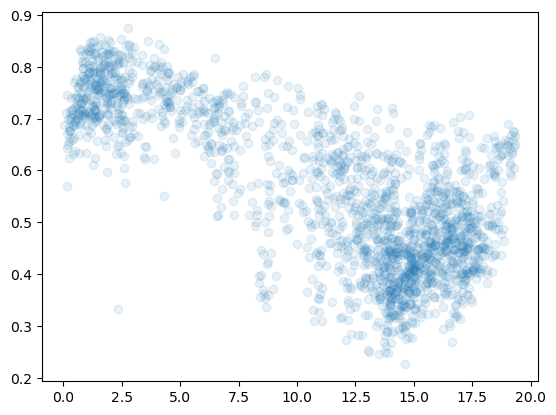

In [14]:
plt.scatter(x = adata_H.obs["pseudotime1to4"], y = adata_H.obs["Cosine_NNs"], alpha=0.1)

In [15]:
plot_x_heart = adata_H.obs["pseudotime1to4"]
plot_y_heart = adata_H.obs["Cosine_NNs"]

In [16]:
# save_dir = "/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/ref_fig6_embryopaper"
# adata_H.write(save_dir + "/adata_heart.h5ad")
# adata_H.obs[["pseudotime1to4", "Cosine_NNs"]].to_csv(save_dir + "/pseudotime_cosine_heart.csv")

In [17]:
from scipy import stats

n_cutoff = 10
cutoff = [np.nanquantile(adata.obs["pseudotime1to4"].values, i/n_cutoff) for i in range(n_cutoff+1)]
cos_list = []
for i in range(n_cutoff):
    adata_tmp = adata_H[(adata_H.obs["pseudotime1to4"] >= cutoff[i]) & (adata_H.obs["pseudotime1to4"] < cutoff[i+1])]
    cos_list.append(np.mean(adata_tmp.obs["Cosine_NNs"]))

In [18]:
cos_list_H = cos_list

In [19]:
# gut

adata_H = adata[adata.obs["orig.ident"] == "ENS_E14", :].copy()
adata_others = adata[adata.obs["orig.ident"] != "ENS_E14", :].copy()
cos_all = np.zeros(adata_H.shape[0],)
for organ in adata_others.obs["orig.ident"].unique():
    adata_others_t = adata_others[adata_others.obs["orig.ident"] == organ, :].copy()
    neigh = NearestNeighbors(n_neighbors=k, metric="cosine")
    # neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(adata_others_t.obsm["X_pca"])
    NN = neigh.kneighbors(adata_H.obsm["X_pca"], k, return_distance=False)
    NN_genelevels = np.zeros(adata_H.obsm["X_pca"].shape)

    for i in range(NN.shape[0]):
        idx = NN[i, :]
        gene_mat = adata_others_t.obsm["X_pca"][idx, :]
        NN_genelevels[i, :] = np.mean(gene_mat, axis=0)
    cos = np.diag(cosine_similarity(adata_H.obsm["X_pca"], NN_genelevels))
    cos_all += cos

# corr = []
# for i in range(NN.shape[0]):
#     psr = scipy.stats.pearsonr(adata_H.obsm["X_pca"].T[:,i], NN_genelevels.T[:,i])[0]
#     corr.append(psr)
# # corr = scipy.stats.spearmanr(adata_H.X.toarray().T, NN_genelevels.T)[0]
# # corr = corr[:adata_H.shape[0], :]
# # corr = corr[:, adata_H.shape[0]:]
# # corr = np.diag(corr)
# adata_H.obs["Cosine_NNs"] = corr

adata_H.obs["Cosine_NNs"] = cos_all / 3

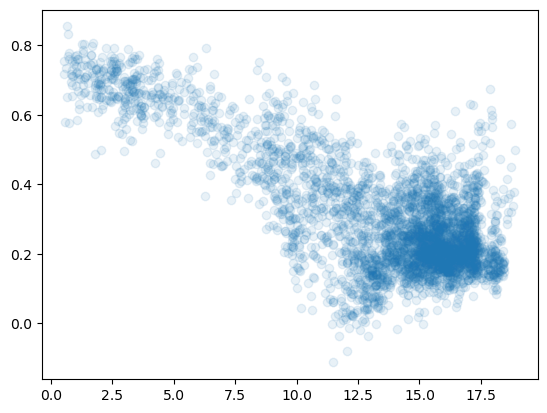

In [20]:
plt.scatter(x = adata_H.obs["pseudotime1to4"], y = adata_H.obs["Cosine_NNs"], alpha=0.1)

In [21]:
plot_x_gut = adata_H.obs["pseudotime1to4"]
plot_y_gut = adata_H.obs["Cosine_NNs"]

In [22]:
# save_dir = "/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/ref_fig6_embryopaper"
# adata_H.write(save_dir + "/adata_gut.h5ad")
# adata_H.obs[["pseudotime1to4", "Cosine_NNs"]].to_csv(save_dir + "/pseudotime_cosine_gut.csv")

In [23]:
from scipy import stats

cos_list = []
for i in range(n_cutoff):
    adata_tmp = adata_H[(adata_H.obs["pseudotime1to4"] >= cutoff[i]) & (adata_H.obs["pseudotime1to4"] < cutoff[i+1])]
    cos_list.append(np.mean(adata_tmp.obs["Cosine_NNs"]))
    # cos_list.append(stats.mode(adata_tmp.obs["Cosine_NNs"])[0][0])

In [24]:
cos_list_G = cos_list

In [25]:
# lung

adata_H = adata[adata.obs["orig.ident"] == "E14.5_Lung", :].copy()
adata_others = adata[adata.obs["orig.ident"] != "E14.5_Lung", :].copy()
cos_all = np.zeros(adata_H.shape[0],)
for organ in adata_others.obs["orig.ident"].unique():
    adata_others_t = adata_others[adata_others.obs["orig.ident"] == organ, :].copy()
    neigh = NearestNeighbors(n_neighbors=k, metric="cosine")
    # neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(adata_others_t.obsm["X_pca"])
    NN = neigh.kneighbors(adata_H.obsm["X_pca"], k, return_distance=False)
    NN_genelevels = np.zeros(adata_H.obsm["X_pca"].shape)

    for i in range(NN.shape[0]):
        idx = NN[i, :]
        gene_mat = adata_others_t.obsm["X_pca"][idx, :]
        NN_genelevels[i, :] = np.mean(gene_mat, axis=0)
    cos = np.diag(cosine_similarity(adata_H.obsm["X_pca"], NN_genelevels))
    cos_all += cos

# corr = []
# for i in range(NN.shape[0]):
#     psr = scipy.stats.pearsonr(adata_H.obsm["X_pca"].T[:,i], NN_genelevels.T[:,i])[0]
#     corr.append(psr)
# # corr = scipy.stats.spearmanr(adata_H.X.toarray().T, NN_genelevels.T)[0]
# # corr = corr[:adata_H.shape[0], :]
# # corr = corr[:, adata_H.shape[0]:]
# # corr = np.diag(corr)
# adata_H.obs["Cosine_NNs"] = corr

adata_H.obs["Cosine_NNs"] = cos_all / 3

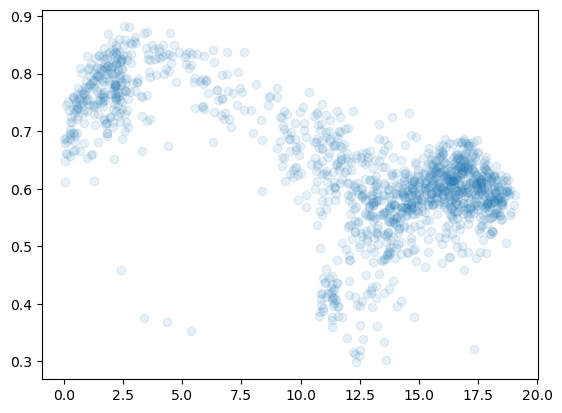

In [26]:
plt.scatter(x = adata_H.obs["pseudotime1to4"], y = adata_H.obs["Cosine_NNs"], alpha=0.1)

In [27]:
plot_x_lung = adata_H.obs["pseudotime1to4"]
plot_y_lung = adata_H.obs["Cosine_NNs"]

In [28]:
# save_dir = "/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/ref_fig6_embryopaper"
# adata_H.write(save_dir + "/adata_lung.h5ad")
# adata_H.obs[["pseudotime1to4", "Cosine_NNs"]].to_csv(save_dir + "/pseudotime_cosine_lung.csv")

In [29]:
from scipy import stats

cos_list = []
for i in range(n_cutoff):
    adata_tmp = adata_H[(adata_H.obs["pseudotime1to4"] >= cutoff[i]) & (adata_H.obs["pseudotime1to4"] < cutoff[i+1])]
    cos_list.append(np.mean(adata_tmp.obs["Cosine_NNs"]))
    # cos_list.append(stats.mode(adata_tmp.obs["Cosine_NNs"])[0][0])

In [30]:
cos_list_L = cos_list

In [31]:
# pan

adata_H = adata[adata.obs["orig.ident"] == "E14.5_pancrease", :].copy()
adata_others = adata[adata.obs["orig.ident"] != "E14.5_pancrease", :].copy()
cos_all = np.zeros(adata_H.shape[0],)
for organ in adata_others.obs["orig.ident"].unique():
    adata_others_t = adata_others[adata_others.obs["orig.ident"] == organ, :].copy()
    neigh = NearestNeighbors(n_neighbors=k, metric="cosine")
    # neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(adata_others_t.obsm["X_pca"])
    NN = neigh.kneighbors(adata_H.obsm["X_pca"], k, return_distance=False)
    NN_genelevels = np.zeros(adata_H.obsm["X_pca"].shape)

    for i in range(NN.shape[0]):
        idx = NN[i, :]
        gene_mat = adata_others_t.obsm["X_pca"][idx, :]
        NN_genelevels[i, :] = np.mean(gene_mat, axis=0)
    cos = np.diag(cosine_similarity(adata_H.obsm["X_pca"], NN_genelevels))
    cos_all += cos

# corr = []
# for i in range(NN.shape[0]):
#     psr = scipy.stats.pearsonr(adata_H.obsm["X_pca"].T[:,i], NN_genelevels.T[:,i])[0]
#     corr.append(psr)
# # corr = scipy.stats.spearmanr(adata_H.X.toarray().T, NN_genelevels.T)[0]
# # corr = corr[:adata_H.shape[0], :]
# # corr = corr[:, adata_H.shape[0]:]
# # corr = np.diag(corr)
# adata_H.obs["Cosine_NNs"] = corr

adata_H.obs["Cosine_NNs"] = cos_all / 3

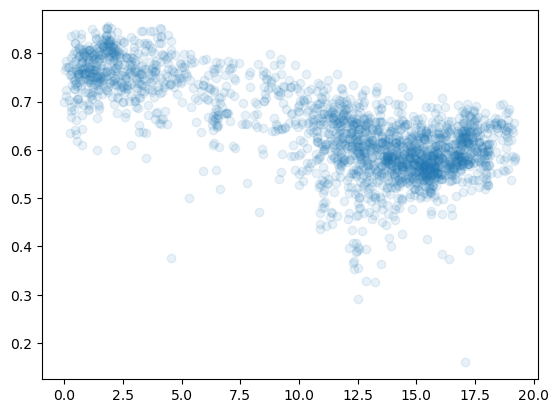

In [32]:
plt.scatter(x = adata_H.obs["pseudotime1to4"], y = adata_H.obs["Cosine_NNs"], alpha=0.1)

In [33]:
plot_x_pan = adata_H.obs["pseudotime1to4"]
plot_y_pan = adata_H.obs["Cosine_NNs"]

In [34]:
# save_dir = "/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/ref_fig6_embryopaper"
# adata_H.write(save_dir + "/adata_pan.h5ad")
# adata_H.obs[["pseudotime1to4", "Cosine_NNs"]].to_csv(save_dir + "/pseudotime_cosine_pan.csv")

In [35]:
from scipy import stats

cos_list = []
for i in range(n_cutoff):
    adata_tmp = adata_H[(adata_H.obs["pseudotime1to4"] >= cutoff[i]) & (adata_H.obs["pseudotime1to4"] < cutoff[i+1])]
    cos_list.append(np.mean(adata_tmp.obs["Cosine_NNs"]))
    # cos_list.append(stats.mode(adata_tmp.obs["Cosine_NNs"])[0][0])

In [36]:
cos_list_P = cos_list

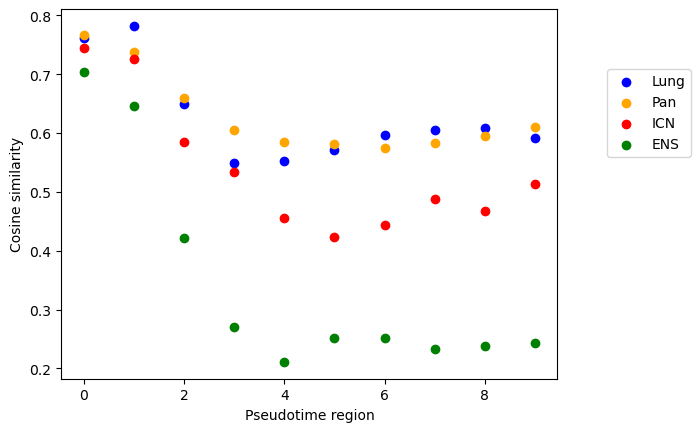

In [37]:
plt.scatter(x = [i for i in range(len(cos_list))], y = cos_list_L, label="Lung", color="blue")
plt.scatter(x = [i for i in range(len(cos_list))], y = cos_list_P, label="Pan", color="orange")
plt.scatter(x = [i for i in range(len(cos_list))], y = cos_list_H, label="ICN", color="red")
plt.scatter(x = [i for i in range(len(cos_list))], y = cos_list_G, label="ENS", color="green")
plt.xlabel("Pseudotime region")
plt.ylabel("Cosine similarity")
plt.legend(loc=[1.1, 0.6])

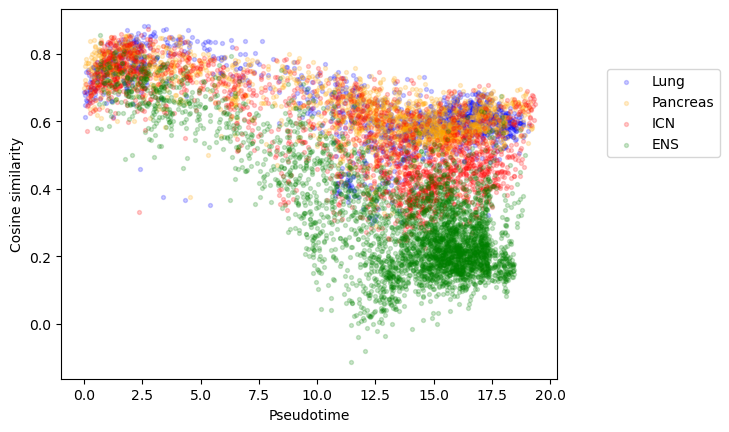

In [38]:
alpha = 0.2
s = 8
plt.scatter(x = plot_x_lung, y = plot_y_lung, label="Lung", color="blue", alpha=alpha, s=s)
plt.scatter(x = plot_x_pan, y = plot_y_pan, label="Pancreas", color="orange", alpha=alpha, s=s)
plt.scatter(x = plot_x_heart, y = plot_y_heart, label="ICN", color="red", alpha=alpha, s=s)
plt.scatter(x = plot_x_gut, y = plot_y_gut, label="ENS", color="green", alpha=alpha, s=s)
plt.xlabel("Pseudotime")
plt.ylabel("Cosine similarity")
plt.legend(loc=[1.1, 0.6])

In [39]:
# alpha = 0.2
# s = 8
# plt.scatter(x = plot_x_lung, y = plot_y_lung, label="Lung", color="#F8766D", alpha=alpha, s=s)
# plt.scatter(x = plot_x_pan, y = plot_y_pan, label="Pancreas", color="#7CAE00", alpha=alpha, s=s)
# plt.scatter(x = plot_x_heart, y = plot_y_heart, label="ICN", color="#00BFC4", alpha=alpha, s=s)
# plt.scatter(x = plot_x_gut, y = plot_y_gut, label="ENS", color="#C77CFF", alpha=alpha, s=s)
# plt.axvline(x=cutoff_1, color='k', lw=1)
# plt.axvline(x=cutoff_2, color='k', lw=1)
# plt.annotate("Precursors", xy=((cutoff_1-0.5)/2, 1.025), ha="center", annotation_clip=False, fontsize=12)
# plt.annotate("Neuroblasts", xy=((cutoff_1+cutoff_2)/2, 1.025), ha="center", annotation_clip=False, fontsize=12)
# plt.annotate("Neurons", xy=((cutoff_2+20)/2, 1.025), ha="center", annotation_clip=False, fontsize=12)
# plt.xlabel("Pseudotime")
# plt.ylabel("Cosine similarity")
# plt.legend(loc=[1.05, .75])
# plt.savefig("/gpfs/gibbs/project/zhao/jz874/rui-lab/Yvonne-ICNs/ref_fig6_embryopaper/organ_pseudotime_cosine_plot.pdf", 
#             bbox_inches="tight", dpi=300)

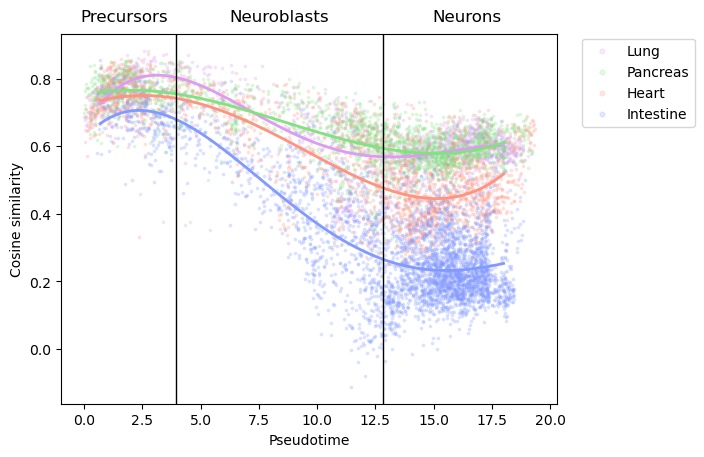

In [42]:
polyline = np.linspace(0.7, 18., 100)

idx = [not np.isnan(plot_x_lung[i]+plot_y_lung[i]) for i in range(len(plot_x_lung))]
model_lung = np.poly1d(np.polyfit(plot_x_lung[idx], plot_y_lung[idx], 4))
idx = [not np.isnan(plot_x_pan[i]+plot_y_pan[i]) for i in range(len(plot_x_pan))]
model_pan = np.poly1d(np.polyfit(plot_x_pan[idx], plot_y_pan[idx], 4))
idx = [not np.isnan(plot_x_heart[i]+plot_y_heart[i]) for i in range(len(plot_x_heart))]
model_heart = np.poly1d(np.polyfit(plot_x_heart[idx], plot_y_heart[idx], 4))
idx = [not np.isnan(plot_x_gut[i]+plot_y_gut[i]) for i in range(len(plot_x_gut))]
model_gut = np.poly1d(np.polyfit(plot_x_gut[idx], plot_y_gut[idx], 4))

alpha = 0.2
s = 3
plt.scatter(x = plot_x_lung, y = plot_y_lung, label="Lung", color="#DE9BF4", alpha=alpha, s=s, edgecolor=None)
plt.scatter(x = plot_x_pan, y = plot_y_pan, label="Pancreas", color="#80E380", alpha=alpha, s=s, edgecolor=None)
plt.scatter(x = plot_x_heart, y = plot_y_heart, label="Heart", color="#FF9380", alpha=alpha, s=s, edgecolor=None)
plt.scatter(x = plot_x_gut, y = plot_y_gut, label="Intestine", color="#8299FF", alpha=alpha, s=s, edgecolor=None)
plt.plot(polyline, model_lung(polyline), color='#DE9BF4', lw=2)
plt.plot(polyline, model_pan(polyline), color='#80E380', lw=2)
plt.plot(polyline, model_heart(polyline), color='#FF9380', lw=2)
plt.plot(polyline, model_gut(polyline), color='#8299FF', lw=2)
plt.axvline(x=cutoff_1, color='k', lw=1)
plt.axvline(x=cutoff_2, color='k', lw=1)
plt.annotate("Precursors", xy=((cutoff_1-0.5)/2, .97), ha="center", annotation_clip=False, fontsize=12)
plt.annotate("Neuroblasts", xy=((cutoff_1+cutoff_2)/2, .97), ha="center", annotation_clip=False, fontsize=12)
plt.annotate("Neurons", xy=((cutoff_2+20)/2, .97), ha="center", annotation_clip=False, fontsize=12)
plt.xlabel("Pseudotime")
plt.ylabel("Cosine similarity")
plt.legend(loc=[1.05, .75], markerscale=2.)
plt.savefig("/gpfs/gibbs/pi/zhao/jz874/project/rui-lab/Yvonne-ICNs/ref_fig6_embryopaper/organ_pseudotime_cosine_plot_withlines_updated.pdf", 
            bbox_inches="tight", dpi=300)